In [1]:
from IPython.display import clear_output
import time
import pandas as pd
from Chandelier_ZLSMA_Filter_Future import *
from Chandelier_ZLSMA import *
from Support_Resistance_Future_Scaner import *
from Display_Future import *
from Buy_Sell_Presure_Scaner import *

In [2]:
btc_out = only_chandelier("BTCUSDT")
btc_out = btc_out[198:]  # Slice the dataframe as per original logic

Fetching BTCUSDT/USDT data from Binance...


In [3]:
btc_out['buy_signal'].sum()

np.int64(0)

In [4]:
scanner = Binance_Support_Resistance_Perpetual_Scanner()
active_symbols = scanner.get_active_symbols()

In [5]:
results_both = Chandelier_ZLSMA_Scan(
    coin_list=active_symbols,
    timeframe='15m',
    chandelier_limit=200,
    zlsma_limit=500,
    atr_period=1,
    atr_multiplier=2.0,
    zlsma_length=200,
    max_signal_candles=3,
    signal_type='both'
)

ZLSMA: Need at least 399 data points, got 284
  MUSDT: ZLSMA value is still NaN - insufficient data or calculation error
  No valid ZLSMA values found - skipping MUSDT
ZLSMA: Need at least 399 data points, got 4
  PUMPUSDT: ZLSMA value is still NaN - insufficient data or calculation error
  No valid ZLSMA values found - skipping PUMPUSDT
ZLSMA: Need at least 399 data points, got 84
  TANSSIUSDT: ZLSMA value is still NaN - insufficient data or calculation error
  No valid ZLSMA values found - skipping TANSSIUSDT
--------------------------------------------------------------------------------
Scan complete. Found 103 coins matching criteria.


In [6]:
results_both = Chandelier_ZLSMA_Scan(
    coin_list=results_both['symbol'].tolist(),
    timeframe='15m',
    chandelier_limit=200,
    zlsma_limit=500,
    atr_period=1,
    atr_multiplier=2.0,
    zlsma_length=200,
    max_signal_candles=3,
    signal_type='both'
)

--------------------------------------------------------------------------------
Scan complete. Found 102 coins matching criteria.


In [7]:
results_both[results_both['current_signal'] == 'BUY']

,symbol,current_price,zlsma_value,price_vs_zlsma,zlsma_percentage,current_signal,signal_candles_count,signal_start_time,current_time,atr_value,long_stop,short_stop,chandelier_exit,prev_buy_time,prev_buy_price,prev_sell_time,prev_sell_price
9,ASRUSDT,2.262000,2.224992,0.037008,1.663291,BUY,2,2025-07-10 08:00:00,2025-07-10 08:15:00,0.010000,2.252000,2.272000,2.252000,NaT,NaN,2025-07-10 07:45:00,2.253000
69,SUNUSDT,0.017617,0.017598,0.000019,0.107519,BUY,2,2025-07-10 08:00:00,2025-07-10 08:15:00,0.000034,0.017583,0.017651,0.017583,NaT,NaN,2025-07-10 07:45:00,0.017569
88,1000000BOBUSDT,0.081240,0.072864,0.008376,11.495135,BUY,3,2025-07-10 07:45:00,2025-07-10 08:15:00,0.001340,0.079900,0.082580,0.079900,NaT,NaN,2025-07-10 07:30:00,0.080820


In [9]:
results_both[results_both['current_signal'] == 'SELL']

,symbol,current_price,zlsma_value,price_vs_zlsma,zlsma_percentage,current_signal,signal_candles_count,signal_start_time,current_time,atr_value,long_stop,short_stop,chandelier_exit,prev_buy_time,prev_buy_price,prev_sell_time,prev_sell_price
0,TSTUSDT,0.041620,0.041736,-0.000116,-0.277063,SELL,1,2025-07-10 08:15:00,2025-07-10 08:15:00,0.000160,0.041640,0.041780,0.041780,2025-07-10 08:00:00,0.041650,NaT,NaN
1,1000CATUSDT,0.007463,0.007641,-0.000178,-2.325353,SELL,2,2025-07-10 08:00:00,2025-07-10 08:15:00,0.000042,0.007421,0.007505,0.007505,2025-07-10 07:45:00,0.007507,NaT,NaN
2,AEVOUSDT,0.090700,0.092823,-0.002123,-2.287465,SELL,2,2025-07-10 08:00:00,2025-07-10 08:15:00,0.000800,0.089900,0.091500,0.091500,2025-07-10 07:45:00,0.091000,NaT,NaN
3,AAVEUSDT,296.750000,300.298633,-3.548633,-1.181701,SELL,2,2025-07-10 08:00:00,2025-07-10 08:15:00,2.800000,293.970000,298.850000,298.850000,2025-07-10 07:45:00,297.130000,NaT,NaN
4,ALTUSDT,0.028500,0.029185,-0.000685,-2.346953,SELL,2,2025-07-10 08:00:00,2025-07-10 08:15:00,0.000380,0.028120,0.028880,0.028880,2025-07-10 07:45:00,0.028760,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,PIXELUSDT,0.034860,0.035195,-0.000335,-0.951322,SELL,3,2025-07-10 07:45:00,2025-07-10 08:15:00,0.000500,0.034370,0.035370,0.035370,2025-07-10 07:30:00,0.035250,NaT,NaN
98,REZUSDT,0.009550,0.009787,-0.000237,-2.419565,SELL,3,2025-07-10 07:45:00,2025-07-10 08:15:00,0.000080,0.009470,0.009630,0.009630,2025-07-10 07:30:00,0.009590,NaT,NaN
99,ORCAUSDT,2.054000,2.076031,-0.022031,-1.061224,SELL,3,2025-07-10 07:45:00,2025-07-10 08:15:00,0.018000,2.036000,2.062000,2.062000,2025-07-10 07:30:00,2.056000,NaT,NaN
100,XAIUSDT,0.052340,0.053389,-0.001049,-1.964133,SELL,3,2025-07-10 07:45:00,2025-07-10 08:15:00,0.000460,0.051880,0.052800,0.052800,2025-07-10 07:30:00,0.052710,NaT,NaN


In [ ]:
# def sup_reg(list_):
#     results_Sup_reg = scanner.scan_multiple_coins(list_['symbol'].tolist())
#     results_Sup_reg = pd.DataFrame(results_Sup_reg)
#     results_Sup_reg
#     return results_Sup_reg

# LONG_sup_reg = sup_reg(results_Chandlier_zlsm_long)
# LONG_sup_reg = LONG_sup_reg[LONG_sup_reg['near_support']== True]
# LONG_sup_reg = LONG_sup_reg[LONG_sup_reg['near_resistance']== False]
# LONG_sup_reg


# SHORT_sup_reg = sup_reg(SHORT_Chandlier_zlsm)
# SHORT_sup_reg = SHORT_sup_reg[SHORT_sup_reg['near_resistance']== True]
# SHORT_sup_reg = SHORT_sup_reg[SHORT_sup_reg['near_support']== False]
# SHORT_sup_reg

In [1]:
from Future_Trade_Execution import *

2025-07-10 17:10:39,082 - INFO - ✅ Connected to Binance Futures successfully!
2025-07-10 17:10:39,082 - INFO - 💰 USDT Balance: $23.46
2025-07-10 17:10:39,083 - INFO - 🛡️ LIQUIDATION-SAFE Futures Trader Ready!
2025-07-10 17:10:39,083 - INFO - 📊 Reports will be saved to: ./futures_reports/


In [11]:
###### ATR Based ######
futures_trader.trade("GLM", 6, leverage=2, side="long", use_fixed_tp=True, fixed_tp_percent=1.5)

2025-07-10 17:13:35,945 - INFO - 📊 Auto-corrected to: GLMUSDT (base: GLM)
2025-07-10 17:13:35,946 - INFO - 🛡️ INITIATING LIQUIDATION-SAFE TRADE: GLM LONG
2025-07-10 17:13:35,947 - INFO - 💰 Margin: $6 | Leverage: 2x | Buffer: 5%
2025-07-10 17:13:35,993 - INFO - ✅ Balance sufficient: $23.42
2025-07-10 17:13:36,059 - INFO - 📊 Current price: $0.24049000
2025-07-10 17:13:36,059 - INFO - 📊 Position Details:
2025-07-10 17:13:36,060 - INFO -    Margin: $6
2025-07-10 17:13:36,060 - INFO -    Leverage: 2x
2025-07-10 17:13:36,060 - INFO -    Notional: $12.00
2025-07-10 17:13:36,060 - INFO -    Quantity: 49.89812466 GLM
2025-07-10 17:13:36,109 - INFO - ⚡ Leverage set to 2x for GLMUSDT
2025-07-10 17:13:36,221 - INFO - 🔒 Margin mode set to isolated for GLMUSDT
2025-07-10 17:13:36,222 - INFO - 📊 Maintenance Margin: 1.00% (tier: $0-$50,000)
2025-07-10 17:13:36,224 - INFO - 🎯 CALCULATED Liquidation Price: $0.11905446
2025-07-10 17:13:36,226 - INFO -    Notional: $12.00
2025-07-10 17:13:36,227 - INFO - 

{'success': True,
 'symbol': 'GLMUSDT',
 'coin': 'GLM',
 'side': 'long',
 'leverage': 2,
 'entry_price': 0.24061,
 'actual_liquidation_price': 0.12126736,
 'quantity': 49.89812466,
 'margin_used': 6,
 'stop_loss': np.float64(0.23927605501650578),
 'take_profit': 0.24409735,
 'tp_type': 'Fixed 1.5%',
 'safety_buffer': np.float64(49.04563194235725)}

In [9]:
###### Fixed Dollar Based ######
#futures_trader.trade("GLM", 6, leverage=2, side="long", fixed_tp_dollars=1, use_atr_stoploss=True, atr_multiplier=1.5)

In [15]:
futures_trader.close_position("GLM")

2025-07-10 17:14:15,072 - INFO - 📊 Auto-corrected to: GLMUSDT (base: GLM)
2025-07-10 17:14:15,073 - INFO - 🔄 CLOSING FUTURES POSITION: GLM
2025-07-10 17:14:15,222 - INFO - 📊 Current price: $0.24046000
2025-07-10 17:14:15,224 - INFO - 📊 Position: LONG 49.00000000 GLM
2025-07-10 17:14:15,226 - INFO - 🔥 EXECUTING CLOSING ORDER...
2025-07-10 17:14:15,276 - INFO - ⚡ Order executed in 0.05 seconds
2025-07-10 17:14:15,277 - INFO - ✅ FUTURES POSITION CLOSED - GLM
2025-07-10 17:14:15,279 - INFO - 💰 Exit Price: $0.24046000
2025-07-10 17:14:15,302 - INFO - 📊 Trade exit recorded: PnL $-0.01 (-0.12%)


True

In [13]:
CSV_PATH = "/home/lisa/Arupreza/LiveBot/Future/futures_reports/futures_trading_report_2025-07-10.csv"

🚀 Starting real-time tracking for GLMUSDT
📊 Updates every 5.0 seconds
🛡️ Liquidation Price: $0.121267
🎯 Close the plot window to stop tracking
📡 Performing initial data fetch...


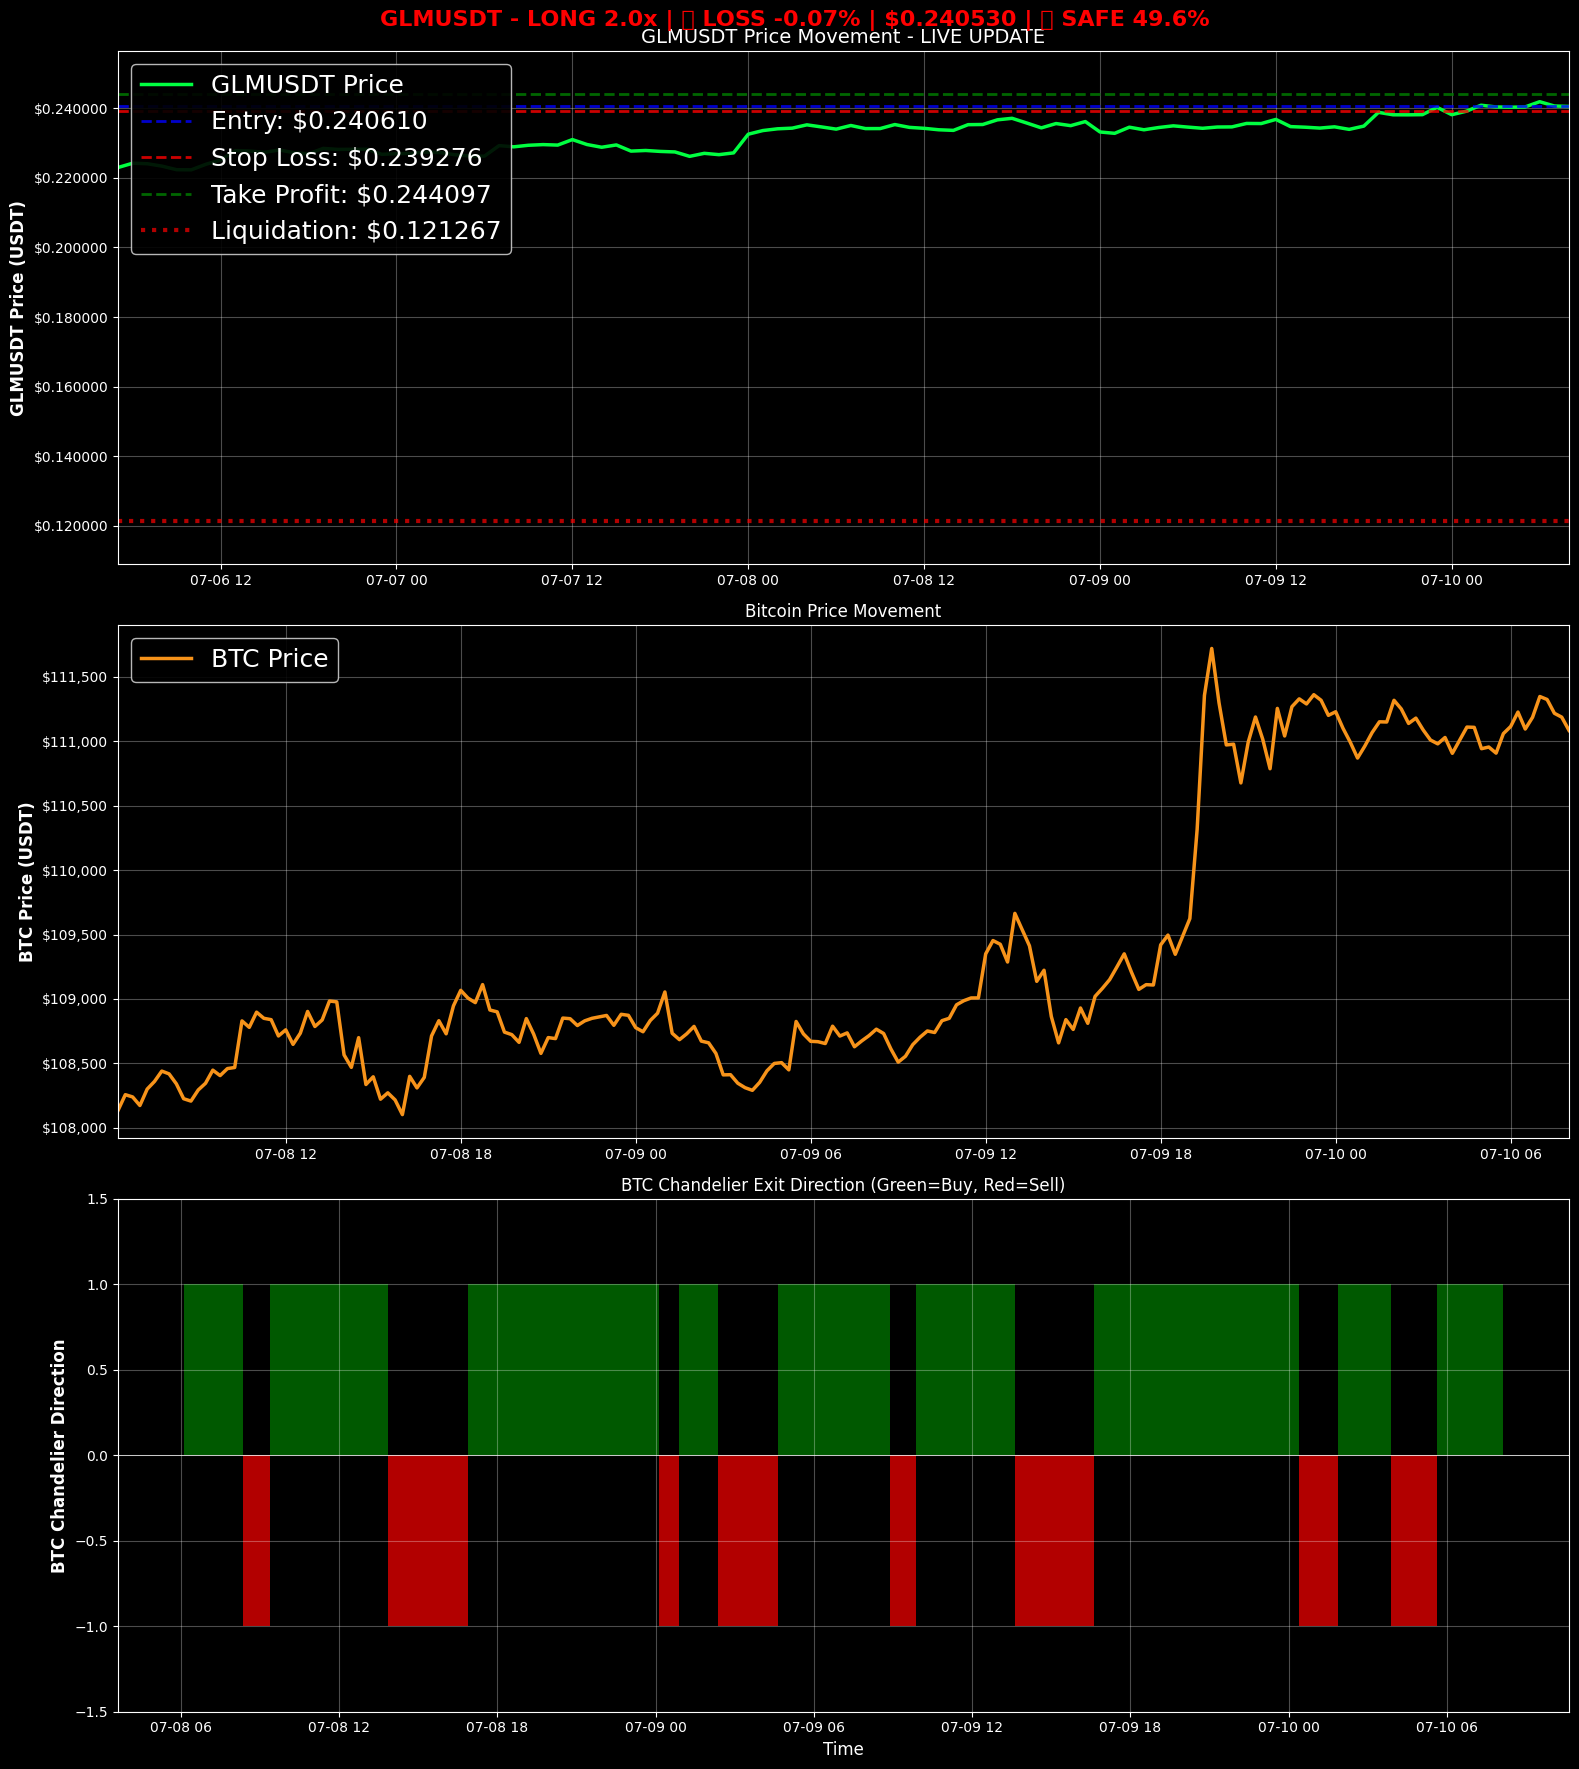

Realtime tracking stopped by user.


In [14]:
from IPython.display import clear_output
from Display_Future import *
import time

try:
    while True:
        # clear last output before plotting the new one
        clear_output(wait=True)
        
        # call your real-time plotting function
        track_perpetual_trade_realtime(CSV_PATH, update_interval=5)
        
        # wait 10 seconds before the next update
        time.sleep(10)

except KeyboardInterrupt:
    print("Realtime tracking stopped by user.")


Loop_In_Bot

In [10]:
from SMC import *
from SMC_FGV import *
from Up_Down_Trend_Scanner import *

from IPython.display import clear_output
import time
import pandas as pd
from Chandelier_ZLSMA_Filter_Future import *
from Chandelier_ZLSMA import *
from Support_Resistance_Future_Scaner import *
from Display_Future import *
from Buy_Sell_Presure_Scaner import *

In [11]:
scanner = Binance_Support_Resistance_Perpetual_Scanner()
active_symbols = scanner.get_active_symbols()

In [12]:
downtrends = downtrend_scanner(active_symbols, timeframe='15m')

Scanning 447 symbols...
Progress: 10/447
Progress: 20/447
Progress: 30/447
Progress: 40/447
Progress: 50/447
Progress: 60/447
Progress: 70/447
Progress: 80/447
Progress: 90/447
Progress: 100/447
Progress: 110/447
Progress: 120/447
Progress: 130/447
Progress: 140/447
Progress: 150/447
Progress: 160/447
Progress: 170/447
Progress: 180/447
Progress: 190/447
Progress: 200/447
Progress: 210/447
Progress: 220/447
Progress: 230/447
Progress: 240/447
Progress: 250/447
Progress: 260/447
Progress: 270/447
Progress: 280/447
Progress: 290/447
Progress: 300/447
Progress: 310/447
Progress: 320/447
Progress: 330/447
Progress: 340/447
Progress: 350/447
Progress: 360/447
Progress: 370/447
Progress: 380/447
Progress: 390/447
Progress: 400/447
Progress: 410/447
Progress: 420/447
Progress: 430/447
Progress: 440/447


In [13]:
downtrends_ = downtrends[downtrends['downtrend_score'] >=  10]

In [14]:
downtrends_

,symbol,trend,score,uptrend_score,downtrend_score,current_price,price_change_5,price_change_10,rsi,volume_ratio,...,down_sma10_below_sma20,down_ema_bearish,down_rsi_bearish,down_macd_bearish,down_volume_decreasing_or_panic,down_lower_highs,down_below_bb_middle,down_momentum_weak,down_momentum_5_negative,down_momentum_10_negative
443,ZKJUSDT,DOWNTREND,11.0,0.0,11.0,0.164100,-1.14,-1.62,35.56,0.66,...,True,True,True,True,True,True,True,True,True,True
418,VOXELUSDT,DOWNTREND,11.0,0.0,11.0,0.051000,-0.78,-1.54,18.52,0.55,...,True,True,True,True,True,True,True,True,True,True
26,AGTUSDT,DOWNTREND,11.0,0.0,11.0,0.009445,-0.20,-1.38,33.15,0.48,...,True,True,True,True,True,True,True,True,True,True
403,TUTUSDT,DOWNTREND,11.0,0.0,11.0,0.062740,-0.40,-0.96,24.58,0.78,...,True,True,True,True,True,True,True,True,True,True
349,SFPUSDT,DOWNTREND,11.0,1.0,11.0,0.473600,-0.25,-0.23,40.54,0.01,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,MTLUSDT,DOWNTREND,10.0,2.0,10.0,0.711000,-0.42,0.14,45.45,0.05,...,True,True,True,True,True,True,True,True,True,False
138,DUSKUSDT,DOWNTREND,10.0,0.0,10.0,0.058900,-0.67,-0.84,38.71,0.34,...,True,True,True,True,True,False,True,True,True,True
294,ORDIUSDT,DOWNTREND,10.0,1.0,10.0,8.390000,-0.83,-0.12,36.25,0.20,...,True,False,True,True,True,True,True,True,True,True
295,OXTUSDT,DOWNTREND,10.0,0.0,10.0,0.054000,-0.55,-0.18,40.00,0.15,...,True,True,True,True,True,False,True,True,True,True


In [ ]:
perp_longs = get_long_signals(downtrends_['symbol'].to_list(), timeframe='15m', market_type='future')

✅ Initialized for Binance PERPETUAL CONTRACTS

🔍 Scanning 43 coins on FUTURE market...
Scanning FVG opportunities for VELODROMEUSDT (future)...
Scanning FVG opportunities for VICUSDT (future)...
Scanning FVG opportunities for ALPINEUSDT (future)...
Scanning FVG opportunities for ARKUSDT (future)...
Scanning FVG opportunities for BSWUSDT (future)...
Scanning FVG opportunities for CAKEUSDT (future)...
Scanning FVG opportunities for CELOUSDT (future)...
Scanning FVG opportunities for BIDUSDT (future)...
Scanning FVG opportunities for BNBUSDT (future)...
Scanning FVG opportunities for SXTUSDT (future)...
Scanning FVG opportunities for DEXEUSDT (future)...
Scanning FVG opportunities for SIGNUSDT (future)...
Scanning FVG opportunities for SYRUPUSDT (future)...
Scanning FVG opportunities for AVAAIUSDT (future)...
Scanning FVG opportunities for GPSUSDT (future)...
Scanning FVG opportunities for FIDAUSDT (future)...
Scanning FVG opportunities for PENGUUSDT (future)...
Scanning FVG opportunities

In [ ]:
perp_longs

""


In [ ]:
# both_markets_df = get_binance_buy_sell_pressure(
#     symbols=symbols,
#     include_both_markets=True,  # Both spot and perpetual
#     apply_filters=True,
#     top_n=20
# )

Modify Chandlier zldma